# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [58]:
STUDENT_NAME = "Võ Lê Phúc Thịnh"  # TODO: Họ và tên
STUDENT_ID = "2510382"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Võ Lê Phúc Thịnh (2510382)


In [59]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: D:\Summer_Projects\ML-IoT\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [60]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [61]:
# TODO N1
# shifted_logits = ...
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)

# exp_logits = ...
exp_logits = np.exp(shifted_logits)

# class_probabilities = ...
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

# predicted_classes = ...
predicted_classes = np.argmax(class_probabilities, axis=1)

# confidence_scores = ...
confidence_scores = np.max(class_probabilities, axis=1)

In [62]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [63]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [64]:
# TODO N2
# train_feature_mean = ...
train_feature_mean = np.mean(X_train, axis=0)

# train_feature_std = ...  
train_feature_std = np.std(X_train, axis=0)

# X_train_scaled = ...
X_train_scaled = (X_train - train_feature_mean) / train_feature_std

# X_val_scaled = ...
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [65]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [66]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [67]:
# TODO N3
# correct_mask = ...
correct_mask = predicted_classes == true_labels

# high_confidence_mask = ...
high_confidence_mask = confidence_scores >= confidence_threshold

# review_mask = ...
review_mask = (~correct_mask) | (~high_confidence_mask)

# review_indices = ...
review_indices = np.where(review_mask)[0]

print("correct_mask:")
print(correct_mask)

print("high_confidence_mask:")
print(high_confidence_mask)

print("review_mask:")
print(review_mask)

print("review_indices:")
print(review_indices)

correct_mask:
[ True False  True False]
high_confidence_mask:
[False False  True False]
review_mask:
[ True  True False  True]
review_indices:
[0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [68]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [69]:
# TODO N4
# normalized_batch = ...
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# augmented_batch = ...
augmented_batch = normalized_batch[:, :, ::-1, :].copy()

# augmented_batch[0, 0, 0, 0] = ...
augmented_batch[0, 0, 0, 0] = 1.0

print("normalized_batch:")
print(normalized_batch)

print("augmented_batch:")
print(augmented_batch)

normalized_batch:
[[[[0.         0.00392157 0.00784314]
   [0.01176471 0.01568628 0.01960784]
   [0.02352941 0.02745098 0.03137255]
   [0.03529412 0.03921569 0.04313726]]

  [[0.04705882 0.05098039 0.05490196]
   [0.05882353 0.0627451  0.06666667]
   [0.07058824 0.07450981 0.07843138]
   [0.08235294 0.08627451 0.09019608]]

  [[0.09411765 0.09803922 0.10196079]
   [0.10588235 0.10980392 0.11372549]
   [0.11764706 0.12156863 0.1254902 ]
   [0.12941177 0.13333334 0.13725491]]

  [[0.14117648 0.14509805 0.14901961]
   [0.15294118 0.15686275 0.16078432]
   [0.16470589 0.16862746 0.17254902]
   [0.1764706  0.18039216 0.18431373]]]


 [[[0.1882353  0.19215687 0.19607843]
   [0.2        0.20392157 0.20784314]
   [0.21176471 0.21568628 0.21960784]
   [0.22352941 0.22745098 0.23137255]]

  [[0.23529412 0.23921569 0.24313726]
   [0.24705882 0.2509804  0.25490198]
   [0.25882354 0.2627451  0.26666668]
   [0.27058825 0.27450982 0.2784314 ]]

  [[0.28235295 0.28627452 0.2901961 ]
   [0.29411766 0.2

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho một mẫu xe trong bộ 1985 Auto Imports.
2. Ký hiệu missing value trong CSV là dấu "?".
3. `symboling` là mức đánh giá rủi ro bảo hiểm có giá trị là một số nguyên nằm trong khoảng từ $-3$ đến $3$.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [70]:
# TODO D1
# raw_df = ...
raw_df = pd.read_csv(DATA_PATH)

# raw_shape = ...
raw_shape = raw_df.shape

# raw_missing_marker_count = ...
raw_missing_marker_count = (raw_df == '?').sum().sum()

display(raw_df)
print(f"raw_shap: {raw_shape[0]} rows, {raw_shape[1]} columns")
print(f"raw_missing_marker_count: {raw_missing_marker_count}")

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


raw_shap: 205 rows, 26 columns
raw_missing_marker_count: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [71]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [72]:
# TODO D2
# df_clean = ...
df_clean = raw_df.replace('?', np.nan)

# for column in NUMERIC_COLUMNS:
#     ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')

# missing_by_column = ...
missing_by_column = df_clean.isna().sum()

display(df_clean)
print("missing values by column:")
print(missing_by_column)


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


missing values by column:
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
* Không nên fill tất cả các numeric columns bằng cùng một giá trị vì mỗi column đại diện cho mỗi thông số khác nhau và mỗi thông số dao động quanh các giá trị khác nhau (có thể khác nhau rất nhiều). Khi đó việc thay thế bằng cùng một giá trị có thể làm sai lệch các tính chất về trung bình, phương sai,... của mỗi thông số.
* `price` là biến mục tiêu quan trọng cần được phân tích và làm rõ, đồng thời chỉ có $4$ mẫu có biến `price` thiếu giá trị. Do đó ta nên lựa chọn drop cho tập dữ liệu để vẫn giữ lại phần lớn số mãu để tính toán.
* cột `normalized_losses` thiếu tới $41$ dữ liệu, chiếm phần lớn mẫu trong tập dữ liệu. Do đó nếu chọn drop, ta vô tình xóa gần $20\%$ lượng dữ liệu. Do đó nên cân nhắc thực hiện fill vào các ô dữ liệu còn thiếu dựa trên trung vị theo từng kiểu thân xe.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [73]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [74]:
# TODO D3
# analysis_df = ...
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).copy()

# X_auto = ...
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)

# auto_feature_mean = ...
auto_feature_mean = np.mean(X_auto, axis=0)

# auto_feature_std = ...
auto_feature_std = np.std(X_auto, axis=0)

# X_auto_scaled = ...
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

display(analysis_df)

print("X_auto:")
print(X_auto, '\n')

print("auto_feature_mean:")
print(auto_feature_mean, '\n')

print("auto_feature_std:")
print(auto_feature_std, '\n')

print("X_auto_scaled:")
print(X_auto_scaled)

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,-1,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,-1,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,-1,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


X_auto:
[[2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.3495e+04]
 [2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.6500e+04]
 [2.8230e+03 1.5200e+02 1.5400e+02 1.9000e+01 2.6000e+01 1.6500e+04]
 ...
 [3.0120e+03 1.7300e+02 1.3400e+02 1.8000e+01 2.3000e+01 2.1485e+04]
 [3.2170e+03 1.4500e+02 1.0600e+02 2.6000e+01 2.7000e+01 2.2470e+04]
 [3.0620e+03 1.4100e+02 1.1400e+02 1.9000e+01 2.5000e+01 2.2625e+04]] 

auto_feature_mean:
[ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ] 

auto_feature_std:
[5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03] 

X_auto_scaled:
[[-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.03160942]
 [-0.01548585  0.07625546  0.20296699 -0.65277647 -0.53912772  0.40918671]
 [ 0.51484142  0.60449348  1.35087746 -0.96354805 -0.68549391  0.40918671]
 ...
 [ 0.87932089  1.10872067  0.81696561 -1.11893383 -1.12459248  1.03555038]
 [ 1.27465576  0.436417

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [75]:
# TODO D4
# price_index = ...
price_index = AUTO_FEATURES.index('price')

# price_z = ...
price_z = X_auto_scaled[:, price_index]

# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2

# price_outliers = ...
price_outliers = analysis_df[price_outlier_mask]

print(f"price_index: {price_index}\n")

print("price_z:")
print(price_z, '\n')

print("price_outlier_mask: ")
print(price_outlier_mask, '\n')

print("price_outliers:")
print(price_outliers)

price_index: 5

price_z:
[ 0.03160942  0.40918671  0.40918671  0.08878002  0.52855391  0.25212461
  0.56122283  0.71325894  1.33585312  0.40039123  0.46258783  0.97084079
  0.9878035   1.4225514   2.20095117  3.52718357  2.96992723 -1.01681153
 -0.87306829 -0.83788638 -0.96391301 -0.86276502 -0.66423852 -0.88136117
 -0.82318537 -0.70796461 -0.58872306 -0.54311223 -0.03511056 -0.84994875
 -0.80270447 -0.9856504  -0.84366626 -0.76827646 -0.74741861 -0.74741861
 -0.6720288  -0.52124918 -0.5526616  -0.37046956 -0.03749791 -0.36418708
 -0.81149995 -0.27585535  2.3881692   2.80281315  2.85935551 -1.01128294
 -0.89819823 -0.81024345 -0.82280842 -0.73485364 -0.28879727 -0.17571256
  0.05045687  0.30175623 -0.5526616  -0.59663899 -0.33277466 -0.37675205
 -0.30764472 -0.25110237  0.63284315  0.64088473  1.54656763  1.88531917
  1.8762724   2.30649691  2.63117569  2.74074221  3.48257793  4.04046252
  0.40956366 -0.9869069  -0.88638716 -0.82607531 -0.69791263 -0.41268786
 -0.59613639 -0.07720321  

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [76]:
# TODO D5
# engine_price_corr = ...
engine_sizes = analysis_df['engine_size'].to_numpy()
prices = analysis_df['price'].to_numpy()
engine_price_corr = np.corrcoef(engine_sizes, prices)
print(f"engine_price_corr: {engine_price_corr[0, 1]:.4f}")

# price_by_body_style = ...
price_by_body_style = analysis_df.groupby('body_style')['price'].mean().sort_index()
display(price_by_body_style)

engine_price_corr: 0.8739


body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

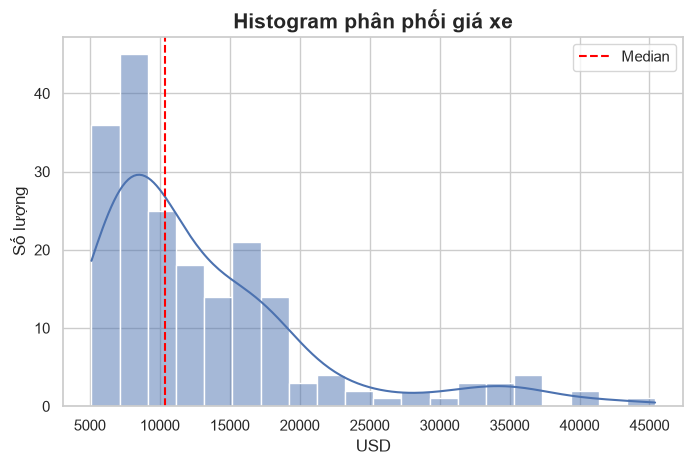

In [77]:
# TODO M2.1: histogram/KDE của price
sns.histplot(data=analysis_df, x="price", kde=True, bins=20)

plt.axvline(analysis_df["price"].median(), color="red", linestyle="--", label="Median")

plt.title("Histogram phân phối giá xe", fontsize=15, fontweight='bold')
plt.xlabel("USD")
plt.ylabel("Số lượng")
plt.legend()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
* Phân phối giá xe có hình dạng ngọn núi với đỉnh nằm lệch về phía bên trái trong khi phần đuôi bị lệch về phía bên phải (có thể gọi phân phối lệch phải).
* Phân phối cho thấy phần lớn số xe đều là xe giá trung bình, rẻ và có khoảng $50\%$ số xe có giá thấp hơn $1000 USD$. Chỉ có số ít ngoại lệ là các xe thuộc phân khúc cao cấp có giá trị cao.

## M2.2 Dataset có cân bằng theo body style không?

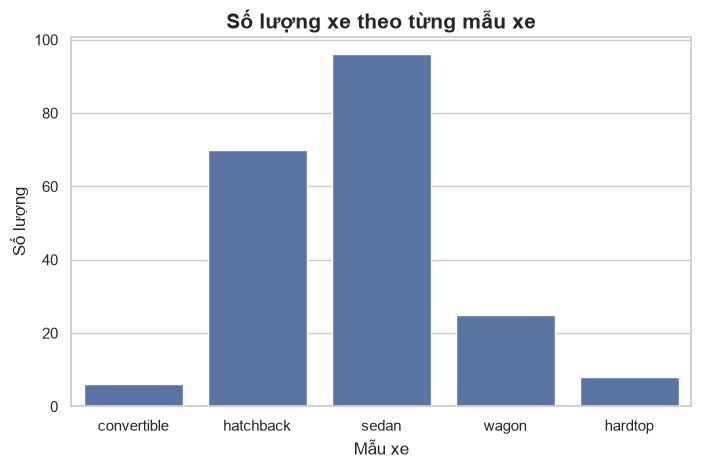

In [85]:
# TODO M2.2: countplot của body_style
sns.countplot(data=df_clean, x='body_style')

plt.title('Số lượng xe theo từng mẫu xe', fontsize=15, fontweight='bold')
plt.xlabel('Mẫu xe')
plt.ylabel('Số lượng')
plt.show()


**Nhận xét:** <!-- 1--2 câu -->
* Số lượng xe theo từng mẫu không cân bằng, mẫu `sedan` và `hatchback` có số lượng vượt trội so với 3 mẫu còn lại.

## M2.3 Price khác nhau theo body style ra sao?

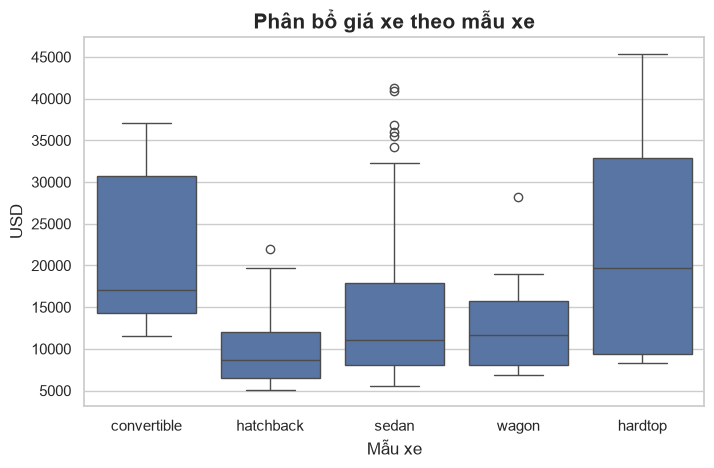

In [86]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')

plt.title('Phân bổ giá xe theo mẫu xe', fontsize=15, fontweight='bold')
plt.xlabel('Mẫu xe')
plt.ylabel('USD')
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
* Trung vị của $2$ mãu xe `convertible` và `hardtop` cao hơn $3$ mẫu xe còn lại. Điều này cho thấy $2$ mẫu xe này thuộc phân khúc xe cao cấp có giá trị cao.
* Mẫu xe `sedan` có độ phân tán rộng cho thấy giá xe trải dài từ phân khúc bình dân đến cao cấp. thậm chí có một vài mẫu xe đặc biệt cao cấp hơn `convertible`.
* Mẫu xe `wagon` có độ phân tán thấp cùng với trung vị nằm thấp cho thấy mẫu xe này tập trung chủ yếu ở phân khúc bình dân.

## M2.4 Engine size liên quan thế nào tới price?

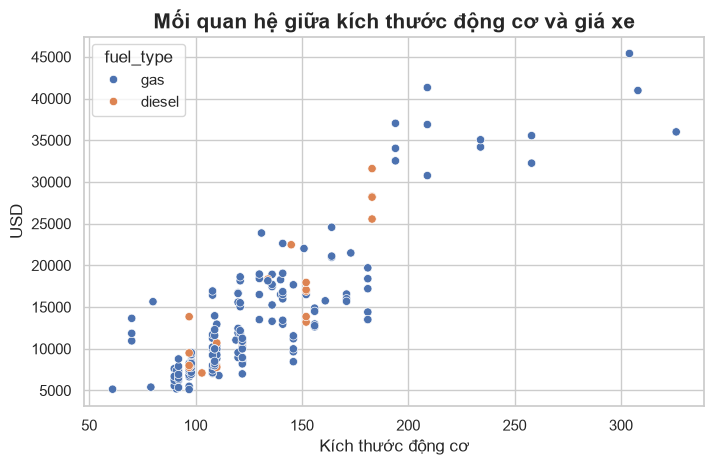

In [88]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type")

plt.title("Mối quan hệ giữa kích thước động cơ và giá xe", fontsize=15, fontweight='bold')
plt.xlabel("Kích thước động cơ")
plt.ylabel("USD")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
* Mối quan hệ tương quan thuận giữa kích thước động cơ và giá xe được quan sát tương đối rõ.

## M2.5 Các feature numeric tương quan ra sao?

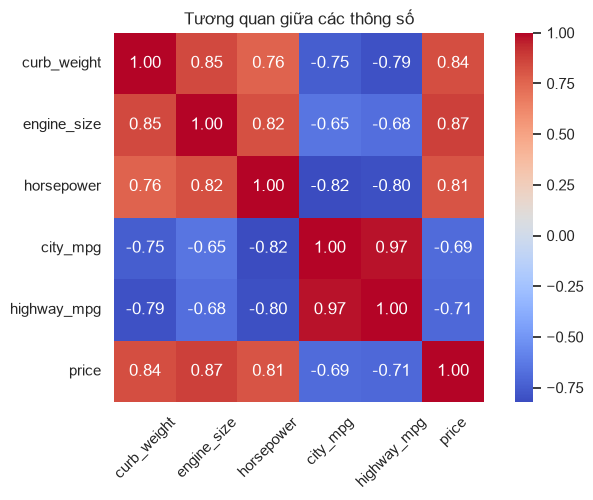

In [91]:
# TODO M2.5: correlation heatmap
corr_matrix = analysis_df[AUTO_FEATURES].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.title("Tương quan giữa các thông số")
plt.xticks(rotation=45)
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
* Thông số quan trọng nhất cần quan sát là `price`. Quan sát mối tương quan của `price` so với các thông số còn lại cho thấy tương quan thuận với `curb_weight`, `engine_size` và `horsepower`. Thực tế giá xe sẽ tăng khi khối lượng xe, kích thước động cơ và mã lực xe càng lớn.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

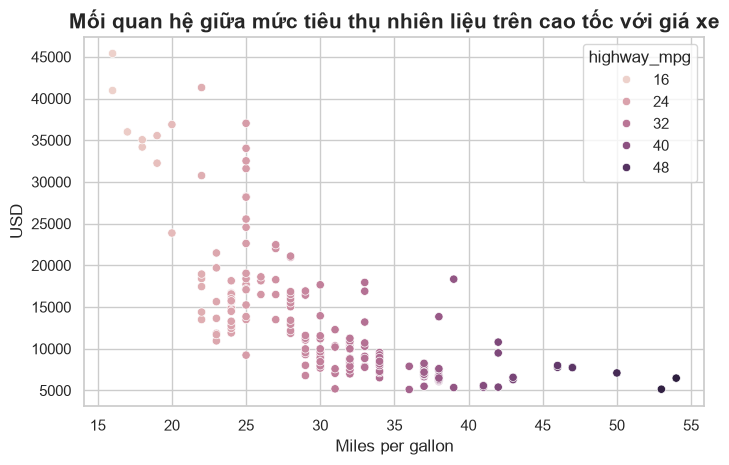

In [99]:
# TODO M2.6: biểu đồ tự chọn
sns.scatterplot(data=analysis_df, x="highway_mpg", y="price", hue="highway_mpg")

plt.title("Mối quan hệ giữa mức tiêu thụ nhiên liệu trên cao tốc với giá xe", fontsize=15, fontweight='bold')
plt.xlabel("Miles per gallon")
plt.ylabel("USD")
plt.show()

**Nhận xét:** <!-- 1--2 câu -->
* Biểu đồ cho thấy giá xe tỷ lệ nghịch với mức tiêu thụ năng lượng khi chạy trên cao tốc. Xe càng rẻ thì càng tiêu tốn ít nhiên liệu, các mẫu xe càng đắt tiền càng tốn nhiều nhiên liệu. 
* Sự tương quan giữa mức tiêu thụ năng lượng trên cao tốc với giá xe khi quan sát sơ lược có thể thấy giảm theo hàm mũ, cho thấy giá xe càng tăng, mức độ tiêu hao năng lượng tăng theo hàm mũ.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->
### Một số phát hiện chính:
* Theo phân phối giá xe, phần lớn giá xe nằm dưới mức $20000 USD$ và có hơn $50\%$ số xe là xe giá rẻ khoảng dưới $10000 USD$.
* Phần lớn các xe được thiết kế theo kiểu `sedan` và `hatchback`. Tuy nhiên 2 kiểu xe này lại là kiểu dáng có giá bán bình dân. Kiểu dáng `hardtop` và `convertible` chiếm phần ít tuy nhiên giá bán lại cao. Điều này cho thấy xe có kiểu dáng càng đặc biệt càng bán với giá cao.
* Mẫu xe `sedan` tuy là mẫu xe bình dân tuy nhiên giá bán lại trải rộng, một số còn cao hơn mẫu `convertible` cho thấy rằng phân khúc xe cao cấp vẫn có một vài xe thiết kế theo kiểu `sedan`. Ngược lại, mẫu `wagon` có giá bán ít trải rộng và giá bán trung vị thấp, thực tế rằng mẫu xe này chỉ bán ở phân khúc bình dân.
### Hạn chế:
* Số lượng mẫu xe không đồng đều về kiểu dáng thiết kế do đó các phần phân tích chưa mang tính khách quan.
* Một số thông số bị mất nhiều giá trị như `normalize losses` gây ảnh hưởng đến quá trình xử lý dữ liệu.
### Ví dụ correlation khác causation:
* Giá bán của xe được cho là tương quan thuận với kích thước động cơ. Tuy nhiên ngoài ra giá bán còn tương quan thuận với cân nặng và mã lực, đồng thời giá bán còn có thể phụ thuộc vào các thông số category như hãng sản xuất, loại nhiên liệu hay cơ chế nạp khí. Do đó nguyên nhân dẫn đến giá bán tăng đến từ nhiều nguồn, các nguồn có thể tương quan thuận với giá bán nhưng không phải là nguyên nhân chính dẫn đến giá bán tăng.
### Nên phân tích tiếp điều gì:
* Một mối liên hệ rất thú vị có thể phân tích đó là phân phối của số cửa xe của mỗi mẫu xe, đồng thời ảnh hưởng của số lượng cửa so với giá bán.